In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rc('text', usetex=False)
plt.rc('font', family='sans-serif')
plt.rc('image', interpolation='none')

In [2]:
from src.KiDS.tomo import calculate_tomo_nz

binning_scheme = "euclid"  # "euclid": native 13-bin DR3 n(z); "kids": old 6-bin KiDS scheme (zmax=2.0)
kids_data_dir = 'KiDS_data/data'  # holds nofzs/nz/*.ascii (+ nofzs/dz/* if kids_shift_nz) for calculate_tomo_nz
kids_shift_nz = False  # apply calculate_tomo_nz's random photo-z dz bias/covariance shift

if binning_scheme == "euclid":
    data = np.loadtxt('KiDS_data/euclid_nzs_dr3.txt')
    z = data[:, 0]
    nz = data[:, 1:]
    zmax_scheme = 3.05  # covers the euclid n(z) support (z up to 3.0)
elif binning_scheme == "kids":
    # Real KiDS photo-z n(z), via src/KiDS/tomo.py:calculate_tomo_nz reading the ascii
    # files under kids_data_dir/nofzs/nz. This preview grid is only for the plot below;
    # calculate_tomo_nz is called again further down on the actual los-integration grid.
    zmax_scheme = 2.05  # KiDS scheme's zmax = 2.0
    z = np.linspace(0.0, zmax_scheme, 1000)
    nz = calculate_tomo_nz(kids_data_dir, len(z), z, shift_nz=kids_shift_nz).T
else:
    raise ValueError(f"unknown binning_scheme: {binning_scheme!r}")

nbins = nz.shape[1]
print(f'binning scheme: {binning_scheme!r}, z range: {z.min()} - {z.max()}, {nbins} tomographic bins')

binning scheme: 'euclid', z range: 0.0 - 3.0, 13 tomographic bins


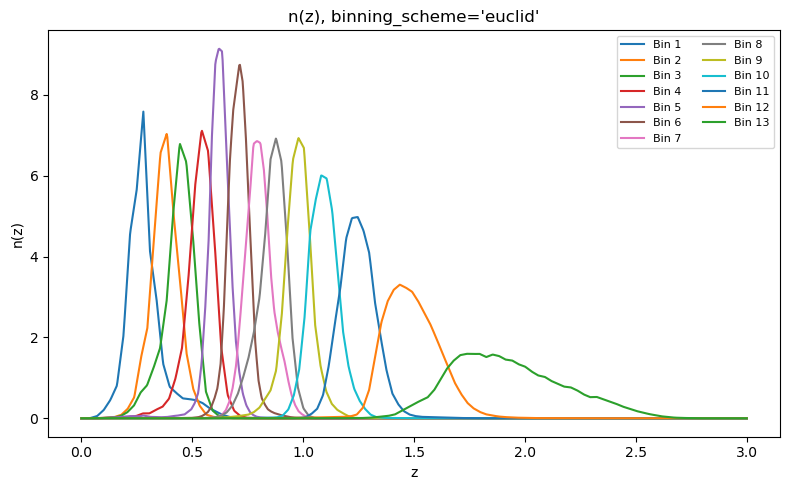

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
for i in range(nbins):
    ax.plot(z, nz[:, i], label=f'Bin {i+1}')
ax.set_xlabel('z')
ax.set_ylabel('n(z)')
ax.set_title(f'n(z), binning_scheme={binning_scheme!r}')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## Footprint: 14,000 deg$^2$ equatorial band

To minimize flat-sky approximation error, the footprint is built as a Dec-band centered on the celestial equator (Dec = 0) spanning the full RA range, rather than a compact cap. This keeps `cos(dec) \approx 1` everywhere in the mask, so RA/Dec behave close to Cartesian coordinates across the whole footprint.

For a symmetric band from `-dec_half` to `+dec_half` covering all RA, the solid angle is `Omega = 4*pi*sin(dec_half)`. Solving for `dec_half` given the target area fixes the band width.

In [4]:
import healpy as hp

mask_nside = 1024  # resolution of the footprint definition itself; downgraded for the simulation nside below
target_area_deg2 = 14000.0

# Solid angle of a symmetric Dec-band spanning full RA: Omega = 4*pi*sin(dec_half)
target_area_sr = target_area_deg2 * np.deg2rad(1.0) ** 2
dec_half_deg = np.rad2deg(np.arcsin(target_area_sr / (4 * np.pi)))

theta_min = np.deg2rad(90.0 - dec_half_deg)  # colatitude, northern edge
theta_max = np.deg2rad(90.0 + dec_half_deg)  # colatitude, southern edge

footprint = np.zeros(hp.nside2npix(mask_nside), dtype=bool)
footprint[hp.query_strip(mask_nside, theta_min, theta_max)] = True

achieved_area_deg2 = footprint.sum() * hp.nside2pixarea(mask_nside, degrees=True)
print(f"Dec range: [{-dec_half_deg:.3f}, {dec_half_deg:.3f}] deg")
print(f"Target area: {target_area_deg2:.1f} deg^2, achieved: {achieved_area_deg2:.1f} deg^2")

Dec range: [-19.838, 19.838] deg
Target area: 14000.0 deg^2, achieved: 14006.1 deg^2


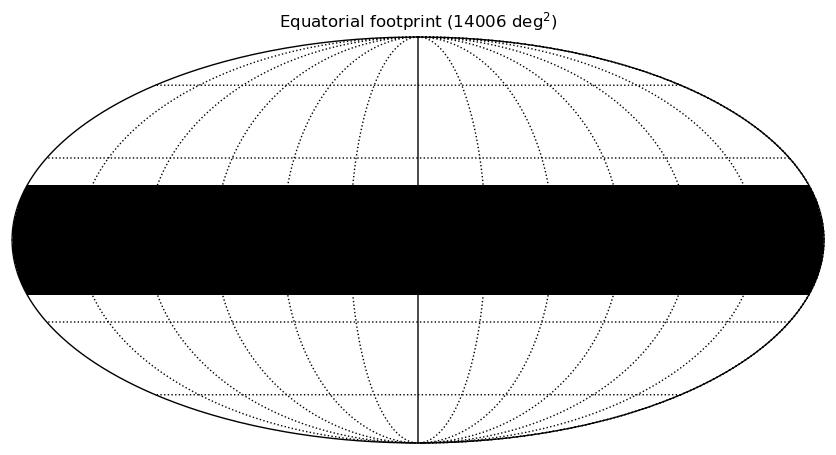

In [5]:
hp.mollview(
    footprint.astype(float),
    title=f"Equatorial footprint ({achieved_area_deg2:.0f} deg$^2$)",
    cbar=False,
    cmap="Greys",
)
hp.graticule()
plt.show()

## Simulating a single lognormal catalogue (no rotations)

This mirrors `master_kids_legacy_simulator.py`, stripped down for a single Euclid-like realisation (see also the `README.md` "Euclid DR3 details" section):

- **`binning_scheme`** toggles between Euclid's native **13 bins** (`euclid_nzs_dr3.txt`, zmax≈3.0) and the old KiDS **6 bins** (`calculate_tomo_nz`, reading the real ascii n(z)s under `KiDS_data/data/nofzs/nz`, zmax=2.0).
- **One footprint**, no `mask_rotation_angles` sweep and no north/south split — the equatorial-band mask built above (README obstacle 3: hoping one patch is enough for this exercise).
- **No augmentation**: `rotation_spec={"rot": [0, 0, 0], "flip": False, "backend": "identity"}`, `mask_rotation_angles=[0]`, `num_shape_noise_realisations=1`.
- **No systematics**: `systematics=None` (defaults to `NoSystematics`, so no NLA/IA, no m/c shear bias).
- **`n_arcmin2_total = 6.2`** for the `"euclid"` scheme, split across bins by each bin's share of the raw (unnormalised) integral of n(z); the `"kids"` scheme instead uses KiDS's own per-bin `n_arcmin2` from `src/KiDS/tomo.py`.
- **`sigma_e = 0.26`** for every bin.
- **Planck 2018 cosmology** as the fixed "ground truth" (README), not a sampled `GowerStPrior`/`GowerStCosmologies` draw — no CAMB subprocess/caching wrapper needed since there's only one cosmology.
- **Limber approximation** (`limber=True`) for the theory Cls, per README obstacle 2 — the exact non-Limber path `get_camb_matter_cls` hardcodes is accepted to be inaccurate at this large footprint/thin-bin combination, but the README explicitly signs off on Limber for this rough forecast.

**Memory caveat:** `n_arcmin2_total=6.2` over 14,000 deg$^2$ implies ≈312 million galaxies in a single realisation (14,000 × 3600 × 6.2), which will not fit as a flat catalogue array on a typical machine (tens of GB). The cells below default to a much smaller `n_arcmin2_total` and `nside` for a fast smoke test; switch to the full values only when running on a machine/job sized for it (e.g. chunked writing to disk instead of `np.concatenate`, as `master_kids_legacy_simulator.py` does per-output-file).

In [6]:
import glass
import glass.ext.camb
from cosmology import Cosmology

from src.cosmology.parameters import build_cosmology
from src.cosmology.camb_matter_power import update_pars_config

n_arcmin2_total = 1 #1. # 6.2  # README: 6.2 galaxies/arcmin^2
sigma_e_val = 0.26  # README: ellipticity dispersion
galaxy_bias = 1
nside = 512
lmax = 2 * nside  # matches SIM_GRID["lmax"] convention in src/KiDS/simulation_config.py
zmin, zmax, dx = 0.0, zmax_scheme, 200 #100.0  # zmax set by the chosen binning_scheme above

rng = np.random.default_rng(12345)

# Planck 2018 (TT,TE,EE+lowE+lensing) fiducial "ground truth" cosmology, per README.
planck2018 = {
    "h": 0.6736,
    "omega_m": 0.3153,
    "ombh2": 0.02237,
    "ns": 0.9649,
    "sigma_8": 0.8111,
    "w0": -1.0,
    "wa": 0.0,
}
cosmo, pars = build_cosmology(planck2018)

# README obstacle 2: assume the Limber approximation (rough forecast) rather than
# the non-Limber Levin path src/cosmology/camb_matter_power.py's get_camb_matter_cls hardcodes.
zb = glass.shells.distance_grid(cosmo, zmin, zmax, dx=dx)
ws = glass.shells.linear_windows(zb)
updated_pars = update_pars_config(pars)
camb_cls = glass.ext.camb.matter_cls(updated_pars, lmax, ws, limber=True)

glass_cls = glass.discretized_cls(camb_cls, nside=nside, lmax=lmax, ncorr=1)
fields = glass.lognormal_fields(ws)
gls = glass.solve_gaussian_spectra(fields, glass_cls)
matter = glass.generate(fields, gls, nside, ncorr=1, rng=rng)

print(f"{len(ws)} shells spanning z=[{zmin}, {zmax}], nside={nside}")

Derived sigma8 and A_s: 0.8111 2.087594882514572e-09
Note: redshifts have been re-sorted (earliest first)
sigma8 from A_s is 0.812153144567101
32 shells spanning z=[0.0, 3.05], nside=512


In [7]:
n_los_chi = 1000  # matches src/KiDS/simulation_config.py's n_los_chi
los_z_integration = np.linspace(ws[0].za[0], ws[-1].za[-1], n_los_chi)

if binning_scheme == "euclid":
    # raw (unnormalised) integral of each bin's n(z) sets its share of n_arcmin2_total
    raw_integrals = np.trapezoid(nz, z, axis=0)
    n_arcmin2 = n_arcmin2_total * raw_integrals / raw_integrals.sum()

    tomo_nz = np.zeros((nbins, n_los_chi))
    for i in range(nbins):
        dndz_interpolated = np.interp(los_z_integration, z, n_arcmin2[i] * nz[:, i] / raw_integrals[i])
        tomo_nz[i] = np.clip(dndz_interpolated, 0, None)
elif binning_scheme == "kids":
    # calculate_tomo_nz already normalises each bin to KiDS's own n_arcmin2 (src/KiDS/tomo.py),
    # so n_arcmin2_total above isn't used for this scheme.
    from src.KiDS.tomo import n_arcmin2 as kids_n_arcmin2
    tomo_nz = calculate_tomo_nz(kids_data_dir, n_los_chi, los_z_integration, shift_nz=kids_shift_nz)
    n_arcmin2 = kids_n_arcmin2

sigma_e = np.full(nbins, sigma_e_val)

print("n_arcmin2 per bin:", np.round(n_arcmin2, 3))
print("total n_arcmin2:", n_arcmin2.sum())

n_arcmin2 per bin: [0.077 0.077 0.077 0.077 0.077 0.077 0.077 0.077 0.077 0.077 0.077 0.077
 0.077]
total n_arcmin2: 0.9999999999999999


In [8]:
from src.cosmology.simulators import GlassMatterShellSimulator

# resample the footprint mask (built at mask_nside) down to the simulation's nside
sim_mask = footprint.astype(float) if nside == mask_nside else hp.ud_grade(footprint.astype(float), nside)

simulator = GlassMatterShellSimulator(
    matter, ws,
    cosmo=cosmo,
    los_z_integration=los_z_integration,
    tomo_nz=tomo_nz,
    galaxy_bias=galaxy_bias,
    sigma_e=sigma_e,
    mask=sim_mask,
    nside=nside,
    nbins=nbins,
    rng=rng,
    systematics=None,  # NoSystematics: no IA, no shear bias
)

identity_rotation = {"rot": [0, 0, 0], "flip": False, "backend": "identity"}
catalogues = simulator.run(
    identity_rotation,
    mask_rotation_angles=[0],
    num_shape_noise_realisations=1,
)
catalogue = np.concatenate(catalogues[0])
print(f"Simulated {len(catalogue):,} galaxies over {achieved_area_deg2:.0f} deg^2")

Using systematics model: NoSystematics()
Total augmentations to be generated: 1
Using rotation backends: identity
Original simulations fixed kappa, partition version
Processing shell 1/32...
Shell 1/32 processed in 6.66 seconds.
Processing shell 2/32...
Shell 2/32 processed in 6.46 seconds.
Processing shell 3/32...
Shell 3/32 processed in 6.66 seconds.
Processing shell 4/32...
Shell 4/32 processed in 6.88 seconds.
Processing shell 5/32...
Shell 5/32 processed in 6.63 seconds.
Processing shell 6/32...
Shell 6/32 processed in 7.54 seconds.
Processing shell 7/32...
Shell 7/32 processed in 6.60 seconds.
Processing shell 8/32...
Shell 8/32 processed in 7.37 seconds.
Processing shell 9/32...
Shell 9/32 processed in 6.84 seconds.
Processing shell 10/32...
Shell 10/32 processed in 6.33 seconds.
Processing shell 11/32...
Shell 11/32 processed in 7.27 seconds.
Processing shell 12/32...
Shell 12/32 processed in 6.71 seconds.
Processing shell 13/32...
Shell 13/32 processed in 6.54 seconds.
Process

## Maps and Cls of the simulated catalogue

Same logic as `master_kids_legacy_simulator.py`'s per-catalogue processing step:

- `make_alm_shear_convergence` (`src/cosmology/map_shears.py`) bins the catalogue's shears onto HEALPix maps per tomographic bin and returns their spin-2 E/B alms, plus alms of a randomly-rotated ("shape noise only") version of the same catalogue.
- `denoise_shear_cls` (`src/cosmology/manip_cls.py`) computes the EE/BB/EB pseudo-Cls for every bin pair and subtracts the shape-noise-only Cls from the diagonal (auto-spectra) — this is the "mixed" (not mask-deconvolved) Cl the master script actually saves; the full mask-unmixing path (`process_cls`/`unmix_shear_cl`) is defined but not used in the active run loop.
- `filter_EB_alms_and_make_maps` (`src/cosmology/map_shears.py`) band-limits the E/B alms (Gaussian beam + cosine taper) and synthesizes E/B maps at a chosen output resolution.

No shear bias was applied (`systematics=None`), so `m_bias=0` for every bin.

In [9]:
from src.cosmology.map_shears import make_alm_shear_convergence, filter_EB_alms_and_make_maps
from src.cosmology.manip_cls import compute_cl_bandpowers, denoise_shear_cls
m_bias = np.zeros(nbins)
lmax_maps = simulator.lmax  # 2*nside - 1, same convention BaseSimulator uses internally

alm, alm_rand = make_alm_shear_convergence(
    catalogue, m_bias, nbins, nside, lmax_maps, mask=sim_mask, nosh=False,
)
mixed_cls = denoise_shear_cls(nbins, alm, alm_rand, lmax_maps)

# nside_out=512 matches the master script's default; capped to nside for the smoke test
nside_out = min(nside, 512)
E, B = filter_EB_alms_and_make_maps(
    alm_list=alm, nside_out=nside_out, lmax_out=None, fwhm_arcmin=8.0, taper_start_frac=0.95
)
print(f"E/B maps: shape {E.shape} at nside_out={nside_out}")

E/B maps: shape (13, 3145728) at nside_out=512


/tmp/ipykernel_15583/3363414029.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


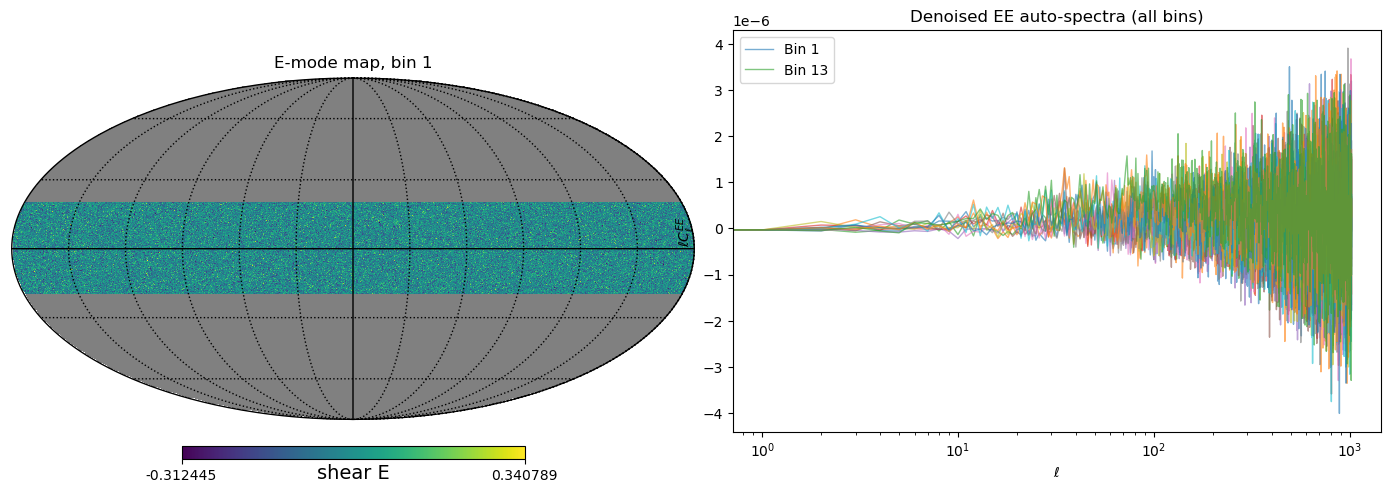

In [10]:
plot_bin = 0  # tomographic bin shown in the map panel

E_masked = E[plot_bin].copy()
mask_out = sim_mask if nside_out == nside else hp.ud_grade(sim_mask, nside_out)
E_masked[mask_out <= 0] = hp.UNSEEN

fig = plt.figure(figsize=(14, 5))
hp.mollview(
    E_masked,
    title=f"E-mode map, bin {plot_bin + 1}",
    unit="shear E",
    fig=fig.number,
    sub=(1, 2, 1),
)
hp.graticule()

ax = fig.add_subplot(1, 2, 2)
ell = np.arange(lmax_maps + 1)
for i in range(nbins):
    dl_ee = ell * mixed_cls[i][i][0] 
    ax.plot(ell, dl_ee, lw=1, alpha=0.6, label=f"Bin {i + 1}" if i in (0, nbins - 1) else None)
ax.set_xscale("log")
ax.set_xlabel(r"$\ell$")
ax.set_ylabel(r"$\ell C_\ell^{EE}$")
ax.set_title("Denoised EE auto-spectra (all bins)")
ax.legend()

plt.tight_layout()
plt.show()

## Cross-check: Cls via heracles

The section above estimates the shape-noise floor with an ad-hoc trick (randomly rotating each galaxy's ellipticity and re-mapping it, then averaging a high-`ell` tail of the resulting "noise-only" Cl) — copied from `master_kids_legacy_simulator.py`/`denoise_shear_cls`. That's sensitive to exactly which `ell` range is averaged, which is presumably why the debiased Cls above look noisy/wrong at low `nside`.

[heracles](https://heracles.readthedocs.io/) (already a dependency, used elsewhere in `src/cosmology/manip_cls.py` for mask-unmixing) computes the same pseudo-Cls directly from the catalogue, but debiases the shape-noise analytically from the catalogue's own per-pixel weight statistics (`fsky * musq / dens`, the standard Poisson shot-noise term for a spin-2 field) rather than a resampled noise realisation. Reusing the catalogue and footprint from above:

1. `heracles.ArrayCatalog` wraps the structured `catalogue` array directly (it already has the `RA`/`DEC`/`E1`/`E2`/`ZBIN` columns heracles expects); one catalogue view per tomographic bin, each with `.visibility` set to the simulation's footprint mask.
2. `heracles.Shears` + `heracles.healpy.HealpixMapper` map each bin's ellipticities to a HEALPix spin-2 map.
3. `heracles.map_catalogs` → `heracles.transform` → `heracles.angular_power_spectra` mirror `make_alm_shear_convergence` → `hp.alm2cl`, but with `debias=True` doing the analytic noise subtraction instead of the random-rotation trick.

In [11]:
import heracles
from heracles.healpy import HealpixMapper

mapper = HealpixMapper(nside, lmax=lmax_maps)
she_field = {"SHE": heracles.Shears(mapper, "RA", "DEC", "E1", "E2")}

# one catalogue view per tomographic bin, 1-indexed to match the repo's
# ("SHE", "SHE", bin_i, bin_j) key convention (src/cosmology/manip_cls.py:to_heracles_cl)
she_catalogs = {}
for i in range(nbins):
    cat = heracles.ArrayCatalog(catalogue[catalogue["ZBIN"] == i])
    cat.visibility = sim_mask  # sets fsky too, needed for the analytic noise bias
    she_catalogs[i + 1] = cat

she_maps = heracles.map_catalogs(she_field, she_catalogs)
she_alms = heracles.transform(she_field, she_maps)
she_cls = heracles.angular_power_spectra(she_alms, lmax=lmax_maps, debias=True)

print(f"Computed {len(she_cls)} Cls, e.g. keys: {list(she_cls)[:3]} ...")

Computed 91 Cls, e.g. keys: [('SHE', 'SHE', 1, 1), ('SHE', 'SHE', 1, 2), ('SHE', 'SHE', 1, 3)] ...


/tmp/ipykernel_15583/692691870.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


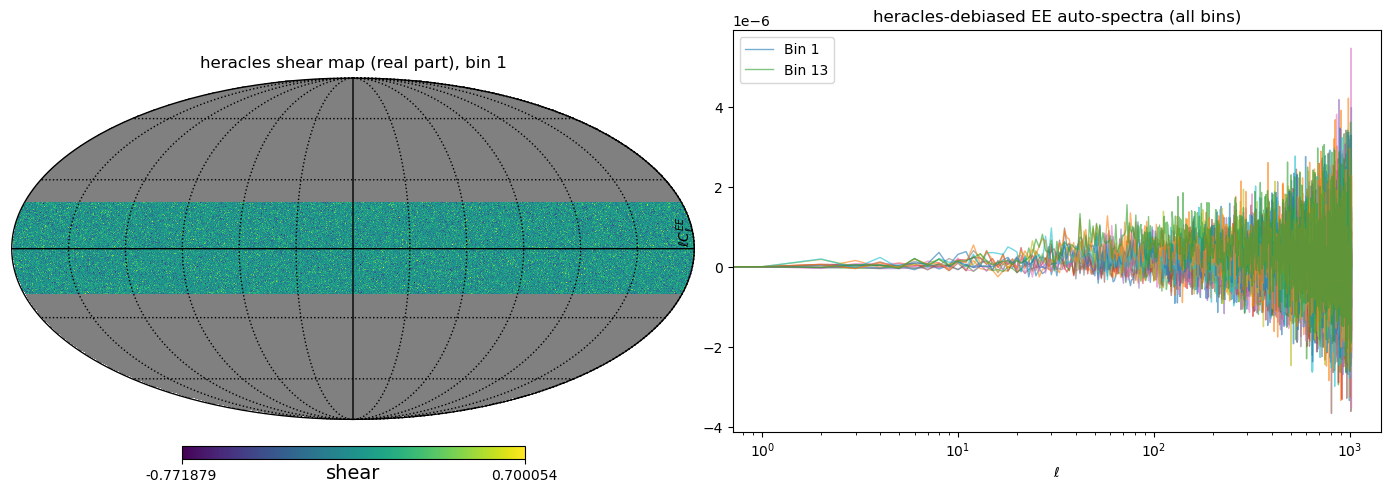

In [12]:
plot_bin = 0  # tomographic bin shown in the map panel
she_map_masked = np.asarray(she_maps[("SHE", plot_bin + 1)])[0].copy()
she_map_masked[sim_mask <= 0] = hp.UNSEEN

fig = plt.figure(figsize=(14, 5))
hp.mollview(
    she_map_masked,
    title=f"heracles shear map (real part), bin {plot_bin + 1}",
    unit="shear",
    fig=fig.number,
    sub=(1, 2, 1),
)
hp.graticule()

ax = fig.add_subplot(1, 2, 2)
ell = np.arange(lmax_maps + 1)
for i in range(nbins):
    cl_ee = np.asarray(she_cls[("SHE", "SHE", i + 1, i + 1)])[0, 0]
    ax.plot(ell, ell * cl_ee, lw=1, alpha=0.6, label=f"Bin {i + 1}" if i in (0, nbins - 1) else None)
ax.set_xscale("log")
ax.set_xlabel(r"$\ell$")
ax.set_ylabel(r"$\ell C_\ell^{EE}$")
ax.set_title("heracles-debiased EE auto-spectra (all bins)")
ax.legend()

plt.tight_layout()
plt.show()